In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import get_data
import matplotlib.pyplot as plt
import population_activity as pop
import helper_functions as hf
import analysis
import plots
import statistics_test as st
import nullspace_drift
import decoding2

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))
from pathlib import Path
OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
datapaths = ['D:/Antje_CA1/data_sig/170.h5', 'D:/Antje_CA1/data_sig/51004.h5', 'D:/Antje_CA1/data_sig/51007.h5', 'D:/Antje_CA1/data_sig/63.h5', 'D:/Antje_CA1/data_sig/64.h5', 'D:/Antje_CA1/data_sig/65.h5']
days1 = [str(i) for i in np.arange(0, 13)] +  ['14', '15', '17', '19']
days2 = ['19','17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]

configs = [
    ('Context1', maps, '0', days1, False, False),  
    ('Context1', None, '0', days1, False, True)
     
]

def run_analysis(datapath, context, sessions, ref_session, days, cross, is_drift):
    if not is_drift:
        res_align = analysis.loop_sessions_2datas(analysis.AK_align_2_sets2, datapath, ref_session, sessions, context, cross, 'dpca', 6)
    else:
        simu_drift = analysis.simulate_drift(
            datapath, session=ref_session, Context=context, days=len(days),
            drift_type='circular', standardize='stand', odd_even=True, 
            global_seed=0, remove_day_inactive=True
        )
        res_align = analysis.loop_sessions_3(
            analysis.AK_align_2_sets_sim, 
            simu_drift['drift_data'][0], 
            simu_drift['drift_data'][1:], 
            simu_drift['pos'],
            'dpca', 6
        )

    translation_scale = [r[8] for r in res_align]
    ref = [r[0][r[2]] for r in res_align]
    align_population = [r[1][r[2]] for r in res_align]
    align_population.insert(0, ref[0])

    pop_correlation = [pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) for day in range(len(res_align))]
    error = [[r[3][6], r[3][5]] for r in res_align]
    rotated_data2 = [r[4] for r in res_align]
    pos_data2 = [r[5] for r in res_align]
    data1 = res_align[0][6]          # (T1,N)
    pos_data1 = res_align[0][7]      # (T1,)

    drift_quadrants = nullspace_drift.split_drift_quadrants(res_align, data1, pos_data1)

    nullpot = nullspace_drift.compute_null_potent_fractions(res_align, data1, pos_data1)

    null_within = nullspace_drift.null_rigid_vs_residual_within_null(res_align, data1, pos_data1)


    return {
        'ref': ref,
        'align_population': align_population,
        'days': days,
        'pop_correlation': pop_correlation,
        'translation_scale': translation_scale,
        'errors': error,
        'drift_quadrants': drift_quadrants,   
        'nullpot': nullpot,
        'null_within': null_within
    }

results = {}
for i, (context, sessions, ref_session, days, cross, is_drift) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift
        )


C:\Users\Ole\AppData\Local\Temp\ipykernel_20020\3723817599.py:51: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


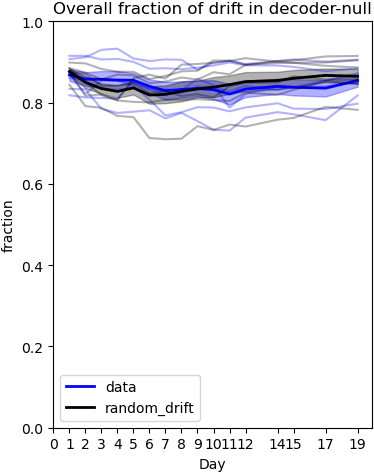

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.027960,15,75,0.001864,3.309634,2.977450e-04,0.084121,0.059214,0.124463
1,condition,0.000083,1,5,0.000083,0.010419,9.226641e-01,0.922664,0.000187,1.000000
2,time * condition,0.015096,15,75,0.001006,5.761173,1.108827e-07,0.010412,0.032866,0.181716


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,-0.6963,0.5173,1.0000,,-0.2843,Cohen's d,0.8678,0.8768,-0.0090,0.0315,6,True,0.2228
1,T2,C1,C2,wilcoxon,9.0000,0.8438,1.0000,,0.1284,r,0.8582,0.8499,0.0083,0.0413,6,False,0.0424
2,T3,C1,C2,t-test,1.8868,0.1178,1.0000,,0.7703,Cohen's d,0.8572,0.8345,0.0227,0.0294,6,True,0.5411
3,T4,C1,C2,t-test,2.7732,0.0392,0.6275,,1.1321,Cohen's d,0.8555,0.8276,0.0279,0.0247,6,True,0.3971
4,T5,C1,C2,t-test,2.0146,0.1001,1.0000,,0.8224,Cohen's d,0.8550,0.8362,0.0188,0.0229,6,True,0.3792
5,T6,C1,C2,t-test,1.3056,0.2485,1.0000,,0.5330,Cohen's d,0.8401,0.8185,0.0216,0.0405,6,True,0.6660
6,T7,C1,C2,t-test,0.4590,0.6655,1.0000,,0.1874,Cohen's d,0.8292,0.8204,0.0088,0.0471,6,True,0.2843
7,T8,C1,C2,t-test,0.2193,0.8351,1.0000,,0.0895,Cohen's d,0.8323,0.8278,0.0045,0.0503,6,True,0.7686
8,T9,C1,C2,t-test,0.0769,0.9417,1.0000,,0.0314,Cohen's d,0.8348,0.8336,0.0012,0.0384,6,True,0.7983
9,T10,C1,C2,t-test,-0.4412,0.6775,1.0000,,-0.1801,Cohen's d,0.8318,0.8381,-0.0063,0.0348,6,True,0.9416


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.015909,15,0.001061,2.962192,0.000982,0.06589,0.186377
1,Error,0.026853,75,0.000358,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.027147,15,0.00181,4.764527,0.000002,0.110426,0.120681
1,Error,0.028489,75,0.00038,NaN,NaN,NaN,NaN


C:\Users\Ole\AppData\Local\Temp\ipykernel_20020\3723817599.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


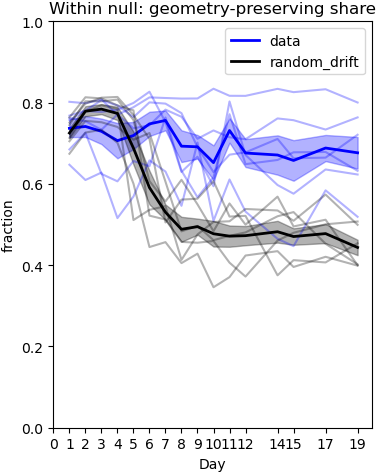

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,1.040126,15,75,0.069342,22.566913,7.474406e-22,0.000013,0.488062,0.190568
1,condition,0.846659,1,5,0.846659,26.506274,3.619665e-03,0.003620,0.436948,1.000000
2,time * condition,0.577983,15,75,0.038532,13.664364,8.332300e-16,0.000027,0.346307,0.250107


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,0.8300,0.4444,1.0000,,0.3388,Cohen's d,0.7368,0.7252,0.0116,0.0344,6,True,0.5058
1,T2,C1,C2,t-test,-2.1727,0.0819,1.0000,,-0.8870,Cohen's d,0.7413,0.7789,-0.0376,0.0424,6,True,0.0878
2,T3,C1,C2,t-test,-1.9839,0.1041,1.0000,,-0.8099,Cohen's d,0.7294,0.7840,-0.0546,0.0674,6,True,0.0635
3,T4,C1,C2,t-test,-1.7967,0.1323,1.0000,,-0.7335,Cohen's d,0.7064,0.7734,-0.0670,0.0913,6,True,0.0646
4,T5,C1,C2,t-test,1.2335,0.2722,1.0000,,0.5036,Cohen's d,0.7190,0.6880,0.0310,0.0616,6,True,0.2461
5,T6,C1,C2,t-test,3.7986,0.0126,0.2024,,1.5508,Cohen's d,0.7476,0.5909,0.1568,0.1011,6,True,0.7692
6,T7,C1,C2,t-test,9.8214,0.0002,0.0030,**,4.0096,Cohen's d,0.7562,0.5302,0.2259,0.0564,6,True,0.1132
7,T8,C1,C2,t-test,4.3421,0.0074,0.1186,,1.7727,Cohen's d,0.6928,0.4883,0.2045,0.1154,6,True,0.9115
8,T9,C1,C2,t-test,4.6534,0.0056,0.0890,,1.8997,Cohen's d,0.6912,0.4948,0.1964,0.1034,6,True,0.4521
9,T10,C1,C2,t-test,3.3713,0.0199,0.3178,,1.3763,Cohen's d,0.6523,0.4773,0.1750,0.1272,6,True,0.7012


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.100193,15,0.006680,2.451277,0.005708,0.120818,0.184854
1,Error,0.204369,75,0.002725,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.517917,15,0.101194,31.945679,1.795126e-26,0.807476,0.217452
1,Error,0.237578,75,0.003168,NaN,NaN,NaN,NaN


C:\Users\Ole\AppData\Local\Temp\ipykernel_20020\3723817599.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


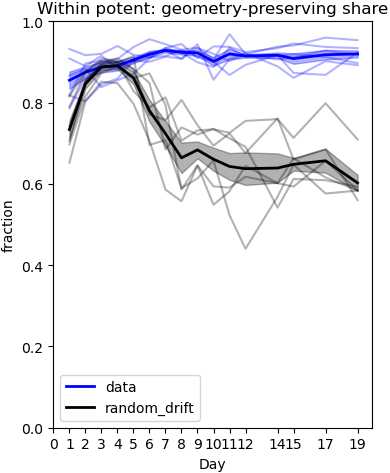

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.362950,15,75,0.024197,12.880203,3.765534e-15,0.000072,0.441087,0.232045
1,condition,1.627685,1,5,1.627685,103.550549,1.572190e-04,0.000157,0.779696,1.000000
2,time * condition,0.556446,15,75,0.037096,17.849653,6.344380e-19,0.000014,0.547495,0.220794


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,2.6884,0.0434,0.6941,,1.0975,Cohen's d,0.8550,0.7336,0.1215,0.1107,6,True,0.2420
1,T2,C1,C2,t-test,1.1140,0.3160,1.0000,,0.4548,Cohen's d,0.8748,0.8460,0.0288,0.0632,6,True,0.6455
2,T3,C1,C2,t-test,-0.0082,0.9938,1.0000,,-0.0034,Cohen's d,0.8874,0.8876,-0.0002,0.0507,6,True,0.4422
3,T4,C1,C2,t-test,-0.0206,0.9844,1.0000,,-0.0084,Cohen's d,0.8908,0.8911,-0.0003,0.0381,6,True,0.4794
4,T5,C1,C2,t-test,2.7850,0.0387,0.6187,,1.1370,Cohen's d,0.9052,0.8610,0.0442,0.0389,6,True,0.9210
5,T6,C1,C2,t-test,4.4792,0.0065,0.1044,,1.8286,Cohen's d,0.9188,0.7802,0.1386,0.0758,6,True,0.3514
6,T7,C1,C2,t-test,6.3451,0.0014,0.0230,*,2.5904,Cohen's d,0.9282,0.7238,0.2044,0.0789,6,True,0.4998
7,T8,C1,C2,t-test,6.5891,0.0012,0.0193,*,2.6900,Cohen's d,0.9238,0.6642,0.2596,0.0965,6,True,0.3736
8,T9,C1,C2,t-test,9.1118,0.0003,0.0043,**,3.7199,Cohen's d,0.9223,0.6836,0.2387,0.0642,6,True,0.3066
9,T10,C1,C2,t-test,7.6337,0.0006,0.0098,**,3.1164,Cohen's d,0.9014,0.6606,0.2408,0.0773,6,True,0.6416


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.036700,15,0.002447,3.612761,0.000106,0.345569,0.214835
1,Error,0.050793,75,0.000677,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.882696,15,0.058846,17.942995,5.484039e-19,0.693345,0.223616
1,Error,0.245972,75,0.003280,NaN,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt

def anova(g, simu_g):
    print_large('\nTWO-WAY REPEATED ANOVA')
    anova=st.repeated_measures_anova_general([np.vstack(g), np.vstack(simu_g)])
    display(anova[0])
    display(anova[1])
    print_large('\nData:')
    display(st.repeated_measures_anova_single_condition(np.vstack(g)))
    print_large('\nRandom Drift:')
    display(st.repeated_measures_anova_single_condition(np.vstack(simu_g)))


def _collect_series(results_cfg, section, field):
    series = []
    for payload in results_cfg.values():
        block = payload.get(section, None)
        if not block: 
            continue
        vals = block.get(field, None)
        if vals is None:
            continue
        series.append(list(vals))
    return series

def plot_overall_null_fraction(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data = _collect_series(results_real_cfg, 'nullpot', 'frac_null')
    g_simu = _collect_series(results_simu_cfg, 'nullpot', 'frac_null')

    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No overall null-fraction data to plot."); 
        return

    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Overall fraction of drift in decoder-null')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()
    fig.savefig(OUT / "fraction_drift_in_nullspace.eps", format="eps")
    
    plt.show()
    anova(g_data, g_simu)

def plot_null_rigid_within_null(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data = _collect_series(results_real_cfg, 'null_within', 'null_rigid_within_null')
    g_simu = _collect_series(results_simu_cfg, 'null_within', 'null_rigid_within_null')

    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No within-null rigid-share data to plot."); 
        return

    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Within null: geometry-preserving share')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()
    fig.savefig(OUT / "fraction_geometry_preserving_in_null.eps", format="eps")
    
    plt.show()
    anova(g_data, g_simu)

def plot_potent_rigid_within_potent(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data = _collect_series(results_real_cfg, 'null_within', 'potent_rigid_within_potent')
    g_simu = _collect_series(results_simu_cfg, 'null_within', 'potent_rigid_within_potent')
    
    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No within-potent rigid-share data to plot.")
        return
    
    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Within potent: geometry-preserving share')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()
    fig.savefig(OUT / "fraction_geometry_preserving_in_potent.eps", format="eps")
    
    plt.show()
    anova(g_data, g_simu)

real_cfg = results['config_1']   
simu_cfg = results['config_2']

day_labels = maps


plot_overall_null_fraction(real_cfg, simu_cfg, day_labels)
plot_null_rigid_within_null(real_cfg, simu_cfg, day_labels)
plot_potent_rigid_within_potent(real_cfg, simu_cfg, day_labels)  


